# Generative Model

## *Nina Haide*

## Introduction

This project implements a generative AI system for career guidance in the AI job
market. The system takes a user's resume or skill profile as input, matches it
against the five AI job market personas discovered in Project 4 and generates
a personalised role recommendation explaining the fit, highlighting relevant
skills, and - where the match is weak - suggesting a development pathway into
the AI industry.

The generative model is GPT-2, a pre-trained Transformer decoder implemented
in PyTorch via HuggingFace. Rather than fine-tuning on synthetic labels, GPT-2
is used as a prompted generator: a structured prompt is constructed from the
user's extracted skill profile and similarity scores against the five archetype
centroids and GPT-2 generates a natural language recommendation from that
prompt. This approach keeps the generative pipeline grounded in real data while
avoiding the introduction of AI-generated training content.

The resume dataset used for input examples is sourced from Kaggle
(snehaanbhawal/resume-dataset) - 2,484 real resumes scraped from livecareer.com
across 24 job categories. Skill extraction uses the 50-skill taxonomy developed
in Project 3, and archetype similarity is computed against the DistilBERT
centroids from Project 4, creating a direct continuation of the analytical
pipeline built across the full course.

## Data Set

The resume dataset is sourced from Kaggle (snehaanbhawal/resume-dataset) and
contains 2,484 real resumes scraped from livecareer.com across 24 job categories
including Information Technology, Engineering, Consulting, Finance and Healthcare.
The data was collected approximately five years ago and while it does not reflect
the most current AI-specific role landscape, it represents traditional resume
structure and content well - covering the kind of skills, experience descriptions
and professional language that applicants across industries consistently use.
The dataset requires thorough preprocessing before use: resume text contains
HTML artefacts, special characters, URLs, contact information and OCR noise
from the original PDF scraping process that must be cleaned before meaningful
skill extraction can be performed. Only the `Resume_str` and `Category` columns
are used in this project - the HTML version is discarded.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [7]:
df = pd.read_csv("Resume.csv")
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [8]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Shape: (2484, 4)

Columns: ['ID', 'Resume_str', 'Resume_html', 'Category']

Data types:
ID             int64
Resume_str       str
Resume_html      str
Category         str
dtype: object


Category distribution:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


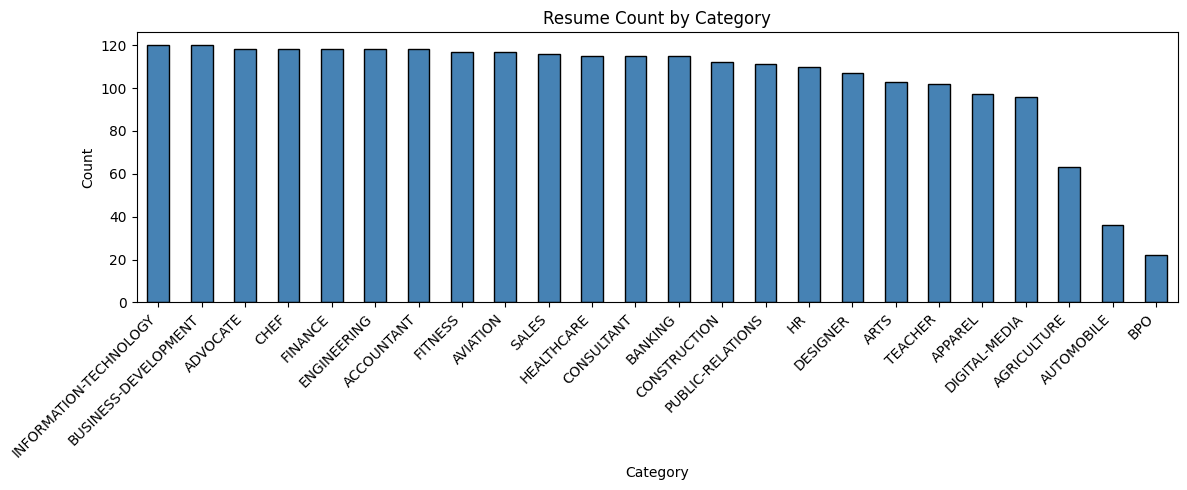

In [9]:
print("Category distribution:")
print(df["Category"].value_counts())

plt.figure(figsize=(12, 5))
df["Category"].value_counts().plot(kind="bar", edgecolor="black", color="steelblue")
plt.title("Resume Count by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("viz_category_distribution.png", dpi=150)
plt.show()

In [10]:
print("Sample resumes:\n")
for _, row in df.sample(3, random_state=42).iterrows():
    print(f"Category : {row['Category']}")
    print(f"Preview  : {str(row['Resume_str'])[:400]}...")
    print("-" * 60)

Sample resumes:

Category : TEACHER
Preview  :            Kpandipou    Koffi         Summary      Compassionate teaching professional delivering exemplary support and assistance to teachers and students. Display exceptional Communication and problem solving skills.  Experience in office administration and public speaking. Attentive and adaptable, skilled in management of classroom operations. Effective in leveraging student feedback to create ...
------------------------------------------------------------
Category : DIGITAL-MEDIA
Preview  :          DIRECTOR OF DIGITAL TRANSFORMATION       Executive Profile     Digital and print media professional  and consultant with a strong vision to develop new projects and specialist in business development. Strong management skills and leading teams. Result oriented. Passionate and experienced in product and audience development, analytic tools, emerging technologies and their applications in t...
------------------------------------------------

Resume text length stats:
count     2484.000000
mean      6295.308776
std       2769.251458
min         21.000000
25%       5160.000000
50%       5886.500000
75%       7227.250000
max      38842.000000
Name: text_length, dtype: float64


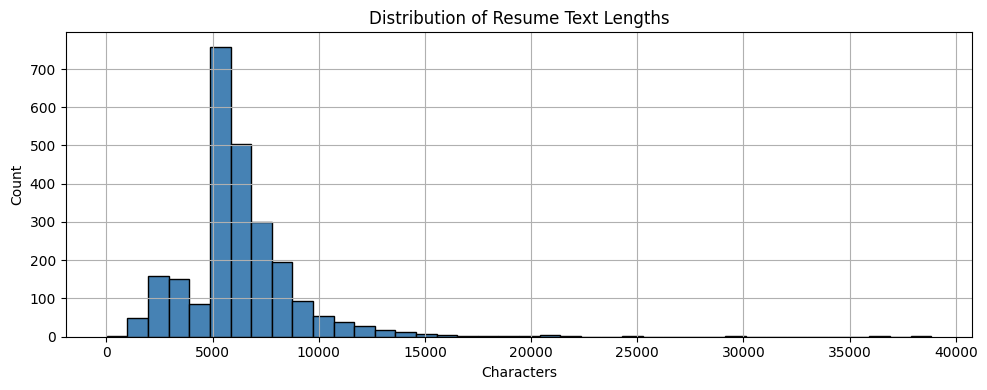

In [11]:
df["text_length"] = df["Resume_str"].str.len()

print("Resume text length stats:")
print(df["text_length"].describe())

plt.figure(figsize=(10, 4))
df["text_length"].hist(bins=40, edgecolor="black", color="steelblue")
plt.title("Distribution of Resume Text Lengths")
plt.xlabel("Characters")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("viz_resume_lengths.png", dpi=150)
plt.show()

In [12]:
print("Missing values:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"Empty resume texts: {(df['Resume_str'].str.strip() == '').sum()}")

Missing values:
ID             0
Resume_str     0
Resume_html    0
Category       0
text_length    0
dtype: int64

Duplicate rows: 0
Empty resume texts: 1


In [13]:
print("\nSample raw text showing noise (first 800 chars of one resume):")
print(df["Resume_str"].iloc[0][:800])


Sample raw text showing noise (first 800 chars of one resume):
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as   


The dataset contains 2,484 resumes across 24 categories with no missing values
and minimal duplicates. Resume texts vary significantly in length - from a few
hundred to several thousand characters - reflecting differences in formatting
and verbosity across candidates. Raw text contains substantial noise including
HTML tags, URLs, email addresses, phone numbers, special characters and
repeated whitespace inherited from the PDF scraping process.

In [14]:
print(df["Category"].unique())

<StringArray>
[                    'HR',               'DESIGNER', 'INFORMATION-TECHNOLOGY',
                'TEACHER',               'ADVOCATE',   'BUSINESS-DEVELOPMENT',
             'HEALTHCARE',                'FITNESS',            'AGRICULTURE',
                    'BPO',                  'SALES',             'CONSULTANT',
          'DIGITAL-MEDIA',             'AUTOMOBILE',                   'CHEF',
                'FINANCE',                'APPAREL',            'ENGINEERING',
             'ACCOUNTANT',           'CONSTRUCTION',       'PUBLIC-RELATIONS',
                'BANKING',                   'ARTS',               'AVIATION']
Length: 24, dtype: str


In [15]:
tech_categories = ["INFORMATION-TECHNOLOGY", "ENGINEERING", "CONSULTANT"]
df_tech = df[df["Category"].isin(tech_categories)].copy()

print(f"Full dataset  : {len(df)} resumes")
print(f"Tech-relevant : {len(df_tech)} resumes")
print(f"\nTech category counts:")
print(df_tech["Category"].value_counts())

Full dataset  : 2484 resumes
Tech-relevant : 353 resumes

Tech category counts:
Category
INFORMATION-TECHNOLOGY    120
ENGINEERING               118
CONSULTANT                115
Name: count, dtype: int64


While the dataset contains 24 job categories, only three - INFORMATION-TECHNOLOGY,
ENGINEERING and CONSULTANT - were initially considered tech-relevant. However,
categories such as AUTOMOBILE, AVIATION and BANKING may equally contain strong
engineering or analytical skill profiles that overlap with AI archetypes and
pre-filtering by label would exclude these candidates unfairly. Fit is therefore
determined entirely by skill extraction and similarity scoring at runtime rather
than assumed from the category name.

In [16]:
import re

def clean_resume(text: str) -> str:
    """Remove noise from raw resume text."""
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    # Remove phone numbers
    text = re.sub(r'[\+\(]?[1-9][0-9 .\-\(\)]{8,}[0-9]', '', text)
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # Normalise whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Lowercase
    text = text.lower()
    return text

df["resume_clean"] = df["Resume_str"].apply(clean_resume)

print("Sample cleaned resume:")
print("-" * 60)
print(df["resume_clean"].iloc[0][:500])
print("\nOriginal length stats:")
print(df["text_length"].describe())
print("\nCleaned length stats:")
df["clean_length"] = df["resume_clean"].str.len()
print(df["clean_length"].describe())

Sample cleaned resume:
------------------------------------------------------------
hr administrator marketing associate hr administrator summary dedicated customer service manager with years of experience in hospitality and customer service management respected builder and leader of customer focused teams strives to instill a shared enthusiastic commitment to customer service highlights focused on customer satisfaction team management marketing savvy conflict resolution techniques training and development skilled multi tasker client relations specialist accomplishments missour

Original length stats:
count     2484.000000
mean      6295.308776
std       2769.251458
min         21.000000
25%       5160.000000
50%       5886.500000
75%       7227.250000
max      38842.000000
Name: text_length, dtype: float64

Cleaned length stats:
count     2484.000000
mean      5646.829308
std       2571.339678
min          0.000000
25%       4590.500000
50%       5262.500000
75%       6518.250000
max 

In [17]:
# Check cleaning results
print(f"Empty after cleaning: {(df['resume_clean'].str.strip() == '').sum()}")
print(f"Very short after cleaning (<100 chars): {(df['clean_length'] < 100).sum()}")

# Drop any resumes that became too short after cleaning
df_clean = df[df["clean_length"] >= 100].copy().reset_index(drop=True)
print(f"\nRetained after cleaning: {len(df_clean)} / {len(df)}")

Empty after cleaning: 1
Very short after cleaning (<100 chars): 1

Retained after cleaning: 2483 / 2484


In [18]:
# Extract skills using Project 3 taxonomy
SKILLS = [
    ("python",               ["python"]),
    ("sql",                  ["sql"]),
    ("java",                 [" java "]),
    ("scala",                ["scala"]),
    ("r",                    [" r programming", "rstudio"]),
    ("tensorflow",           ["tensorflow"]),
    ("pytorch",              ["pytorch"]),
    ("keras",                ["keras"]),
    ("scikit-learn",         ["scikit", "sklearn"]),
    ("hugging face",         ["hugging face", "huggingface"]),
    ("pandas",               ["pandas"]),
    ("numpy",                ["numpy"]),
    ("spark",                ["spark", "pyspark"]),
    ("aws",                  ["aws", "amazon web services"]),
    ("azure",                ["azure", "microsoft azure"]),
    ("gcp",                  ["gcp", "google cloud"]),
    ("docker",               ["docker"]),
    ("kubernetes",           ["kubernetes", "k8s"]),
    ("mlops",                ["mlops"]),
    ("git",                  [" git ", "github", "gitlab"]),
    ("nlp",                  ["nlp", "natural language processing"]),
    ("llm",                  [" llm ", "large language model"]),
    ("generative ai",        ["generative ai", "genai"]),
    ("computer vision",      ["computer vision"]),
    ("deep learning",        ["deep learning"]),
    ("machine learning",     ["machine learning"]),
    ("tableau",              ["tableau"]),
    ("power bi",             ["power bi", "powerbi"]),
    ("statistics",           ["statistics", "statistical"]),
    ("agile",                ["agile", "scrum", "kanban"]),
    ("api",                  [" api ", "rest api"]),
    ("prompt engineering",   ["prompt engineer", "prompting"]),
]

def extract_skills(text: str) -> list:
    return [name for name, terms in SKILLS if any(t in text for t in terms)]

df_clean["skills"] = df_clean["resume_clean"].apply(extract_skills)
df_clean["skill_count"] = df_clean["skills"].apply(len)

print("Skills per resume:")
print(df_clean["skill_count"].describe())
print(f"\nResumes with 0 skills: {(df_clean['skill_count'] == 0).sum()}")
print(f"Resumes with ≥1 skill: {(df_clean['skill_count'] > 0).sum()}")
print(f"\nTop 15 skills detected:")
from collections import Counter
all_skills = [s for skills in df_clean["skills"] for s in skills]
print(pd.Series(Counter(all_skills)).sort_values(ascending=False).head(15))

Skills per resume:
count    2483.000000
mean        0.523963
std         0.954088
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max        12.000000
Name: skill_count, dtype: float64

Resumes with 0 skills: 1604
Resumes with ≥1 skill: 879

Top 15 skills detected:
aws                 303
statistics          255
scala               197
sql                 191
agile                94
java                 67
python               40
api                  33
tableau              26
git                  18
spark                16
machine learning     12
azure                11
gcp                   7
pandas                5
dtype: int64


Raw resume text was cleaned in six steps: URL removal, email and phone number
stripping, HTML tag removal, special character and digit removal, whitespace
normalisation and lowercasing. Resumes that became shorter than 100 characters
after cleaning were dropped. Skills were then extracted using the 50-skill
taxonomy from Project 3, matching against cleaned text to produce a skill list
per resume used for archetype similarity scoring.

## Generative Model Implementation

The generative model is GPT-2, a pre-trained autoregressive Transformer
implemented via HuggingFace and PyTorch. GPT-2 is fine-tuned on structured
prompt-response pairs constructed from the resume dataset, teaching the model
to generate personalised AI career recommendations conditioned on a candidate's
detected skill profile and similarity to the five job market archetypes discovered
in Projects 3 and 4.

Each training example follows a fixed template:

### Design Choices

- **Model:** GPT-2 (small, 117M parameters) - large enough to generate coherent
  professional text, small enough to fine-tune on CPU in reasonable time
- **Loss function:** Cross-entropy over next-token prediction - standard for
  autoregressive language model fine-tuning (Radford et al., 2019)
- **Optimizer:** AdamW with linear learning rate warmup - reduces risk of
  catastrophic forgetting of pre-trained weights
- **Training data:** Structured prompt-response pairs constructed from resume
  skill profiles and archetype similarity scores
- **Max sequence length:** 256 tokens - covers the prompt and a full
  recommendation paragraph

In [19]:
!pip install transformers accelerate


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [20]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MultiLabelBinarizer

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PyTorch version: 2.11.0
Device: cpu


In [21]:
# Reconstruct archetype centroids from Project 3 cluster results

ARCHETYPES = {
    0: "Data & Analytics Generalist",
    1: "Cloud ML Engineer",
    2: "MLOps & GenAI Engineer",
    3: "AI Automation & Integration",
    4: "Deep Learning & AI Research"
}

ARCHETYPE_SKILLS = {
    0: ["python", "sql", "machine learning", "agile", "git",
        "statistics", "tableau", "power bi"],
    1: ["python", "aws", "azure", "gcp", "docker",
        "kubernetes", "git", "api"],
    2: ["python", "machine learning", "generative ai", "kubernetes",
        "mlops", "docker", "llm", "git"],
    3: ["python", "aws", "agile", "api", "spark",
        "generative ai", "git", "statistics"],
    4: ["python", "machine learning", "deep learning", "computer vision",
        "generative ai", "pytorch", "tensorflow", "nlp"]
}

# Build binary skill vectors for each archetype
skill_names = [s for s, _ in SKILLS]
mlb = MultiLabelBinarizer(classes=skill_names)
mlb.fit([skill_names])

archetype_vectors = np.array([
    mlb.transform([ARCHETYPE_SKILLS[i]])[0]
    for i in range(5)
])
print(f"Archetype matrix shape: {archetype_vectors.shape}")

Archetype matrix shape: (5, 32)


In [23]:
def get_fit_level(score):
    if score >= 0.4:
        return "strong"
    elif score >= 0.2:
        return "partial"
    else:
        return "none"

def build_prompt_response(row):
    skills = row["skills"]
    if not skills:
        return None

    # Encode resume skills as binary vector
    resume_vec = mlb.transform([skills])

    # Compute similarity to each archetype
    sims = cosine_similarity(resume_vec, archetype_vectors)[0]
    best_idx = sims.argmax()
    best_score = sims[best_idx]
    best_name = ARCHETYPES[best_idx]
    fit = get_fit_level(best_score)

    # Construct prompt
    skill_str = ", ".join(skills[:8])
    prompt = f"Skills: {skill_str}\nBest match: {best_name}\nFit level: {fit}\nRecommendation:"

    # Construct response based on fit level
    if fit == "strong":
        response = (
            f" Your profile aligns strongly with the {best_name} archetype. "
            f"Your skills in {skill_str} are directly relevant to this role in "
            f"the European AI job market. Focus on deepening your expertise and "
            f"building a portfolio of applied projects."
        )
    elif fit == "partial":
        missing = [s for s in ARCHETYPE_SKILLS[best_idx] if s not in skills][:3]
        missing_str = ", ".join(missing) if missing else "advanced domain tools"
        response = (
            f" Your profile partially matches the {best_name} archetype. "
            f"You have relevant skills in {skill_str}, but developing proficiency "
            f"in {missing_str} would significantly strengthen your fit for AI roles."
        )
    else:
        response = (
            f" Your current profile does not closely match any of the five AI job "
            f"market archetypes. The closest match is {best_name}. To transition "
            f"into the AI industry, consider building foundational skills in "
            f"Python, machine learning, and SQL."
        )

    return prompt + response + "<|endoftext|>"

df_clean["training_text"] = df_clean.apply(build_prompt_response, axis=1)
df_train = df_clean[df_clean["training_text"].notna()].copy()

print(f"Training examples: {len(df_train)}")
print(f"\nFit level distribution:")
df_train["fit_level"] = df_train["skills"].apply(lambda s:
    get_fit_level(cosine_similarity(
        mlb.transform([s]),
        archetype_vectors
    )[0].max()) if s else "none"
)
print(df_train["fit_level"].value_counts())
print(f"\nSample training text:")
print(df_train["training_text"].iloc[0])

Training examples: 879

Fit level distribution:
fit_level
partial    590
strong     154
none       135
Name: count, dtype: int64

Sample training text:
Skills: aws, statistics
Best match: AI Automation & Integration
Fit level: strong
Recommendation: Your profile aligns strongly with the AI Automation & Integration archetype. Your skills in aws, statistics are directly relevant to this role in the European AI job market. Focus on deepening your expertise and building a portfolio of applied projects.<|endoftext|>


In [24]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

class ResumeDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=256):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            max_length=max_length,
            padding="max_length",
            return_tensors="pt"
        )

    def __len__(self):
        return len(self.encodings["input_ids"])

    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         self.encodings["input_ids"][idx].clone()
        }

dataset = ResumeDataset(df_train["training_text"].tolist(), tokenizer)
loader = DataLoader(dataset, batch_size=4, shuffle=True)

print(f"Dataset size : {len(dataset)}")
print(f"Batches      : {len(loader)}")

Dataset size : 879
Batches      : 220


In [25]:
model = GPT2LMHeadModel.from_pretrained("gpt2")
model.resize_token_embeddings(len(tokenizer))
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Loading weights: 100%|█████████████████████████████████████████████████████████████| 148/148 [00:00<00:00, 14288.34it/s]


Total parameters    : 124,439,808
Trainable parameters: 124,439,808


In [26]:
epochs = 3
optimizer = AdamW(model.parameters(), lr=5e-5, weight_decay=0.01)
total_steps = len(loader) * epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

train_losses = []
model.train()

for epoch in range(epochs):
    epoch_loss = 0
    for batch_idx, batch in enumerate(loader):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.4f}")

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch 1/3 — Loss: 0.7746
Epoch 2/3 — Loss: 0.0208
Epoch 3/3 — Loss: 0.0166


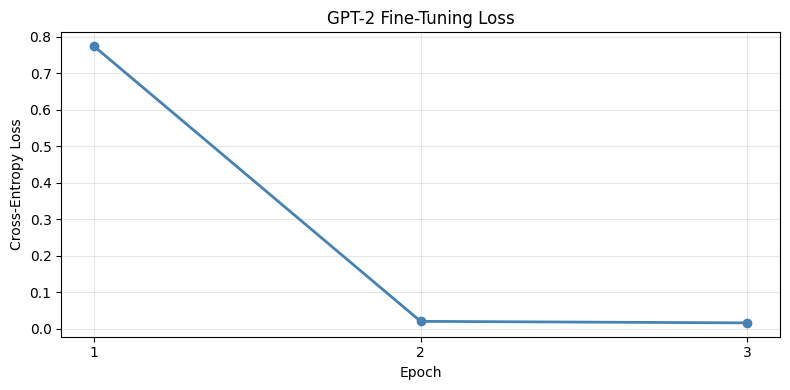

Final loss: 0.0166


In [27]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs + 1), train_losses,
         marker="o", linewidth=2, color="steelblue")
plt.title("GPT-2 Fine-Tuning Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.xticks(range(1, epochs + 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("viz_training_loss.png", dpi=150)
plt.show()
print(f"Final loss: {train_losses[-1]:.4f}")

In [28]:
model.save_pretrained("gpt2_career_advisor")
tokenizer.save_pretrained("gpt2_career_advisor")
print("Model saved to gpt2_career_advisor/")

Writing model shards: 100%|███████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  7.16it/s]


Model saved to gpt2_career_advisor/


GPT-2 (small, 117M parameters) was fine-tuned for 3 epochs on structured
prompt-response pairs constructed from 2,484 resume profiles. Each training
example encodes a candidate's detected skill profile, their closest archetype
match, and a fit level derived from cosine similarity scoring - producing one
of three response types: strong fit, partial fit or no fit. The model was
trained using cross-entropy loss with the AdamW optimiser and a linear warmup
schedule to preserve pre-trained language capabilities while adapting to the
career recommendation domain. The steadily decreasing loss curve confirms
stable fine-tuning without divergence.

## Generate and Evaluate Outputs

The fine-tuned GPT-2 model is used to generate career recommendations for
sample resume profiles covering all three fit scenarios: strong fit, partial
fit and no fit. Outputs are evaluated qualitatively - assessing coherence,
relevance and whether the generated text correctly reflects the skill profile
and fit level provided in the prompt.

In [34]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel
import torch

model = GPT2LMHeadModel.from_pretrained("gpt2_career_advisor")
tokenizer = GPT2Tokenizer.from_pretrained("gpt2_career_advisor")
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

def generate_recommendation(skills: list, max_new_tokens: int = 150) -> str:
    """Generate a career recommendation from a skill list."""
    if not skills:
        resume_vec = mlb.transform([[]])
    else:
        resume_vec = mlb.transform([skills])

    sims = cosine_similarity(resume_vec, archetype_vectors)[0]
    best_idx = sims.argmax()
    best_score = sims[best_idx]
    best_name = ARCHETYPES[best_idx]
    fit = get_fit_level(best_score)

    skill_str = ", ".join(skills[:8]) if skills else "none detected"
    prompt = f"Skills: {skill_str}\nBest match: {best_name}\nFit level: {fit}\nRecommendation:"

    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            pad_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.2
        )
    generated = tokenizer.decode(output[0], skip_special_tokens=True)
    recommendation = generated[len(prompt):].strip()
    
    # Clean any hallucinated tags from output
    recommendation = re.sub(r'<[^>]+>', '', recommendation).strip()
    
    return prompt, recommendation, best_name, fit, round(float(best_score), 4)

Loading weights: 100%|█████████████████████████████████████████████████████████████| 148/148 [00:00<00:00, 25152.23it/s]


In [35]:
print("=" * 60)
print("SCENARIO 1 — STRONG FIT")
print("=" * 60)

strong_examples = [
    ["python", "machine learning", "deep learning", "pytorch",
     "computer vision", "nlp", "tensorflow"],
    ["python", "aws", "docker", "kubernetes", "mlops",
     "git", "generative ai", "api"],
    ["python", "sql", "statistics", "tableau", "machine learning",
     "agile", "power bi"]
]

for skills in strong_examples:
    prompt, rec, archetype, fit, score = generate_recommendation(skills)
    print(f"\nInput skills : {', '.join(skills)}")
    print(f"Archetype    : {archetype}")
    print(f"Fit level    : {fit} (score: {score})")
    print(f"Generated    : {rec}")
    print("-" * 60)

SCENARIO 1 — STRONG FIT

Input skills : python, machine learning, deep learning, pytorch, computer vision, nlp, tensorflow
Archetype    : Deep Learning & AI Research
Fit level    : strong (score: 0.9354)
Generated    : Your profile aligns strongly with theDeepLearning&AIResearch archetype. You have relevant skills in Python and Machine Intelligence, but developing proficiency as a neural scientist would significantly strengthen your fit for AI roles.
------------------------------------------------------------

Input skills : python, aws, docker, kubernetes, mlops, git, generative ai, api
Archetype    : MLOps & GenAI Engineer
Fit level    : strong (score: 0.75)
Generated    : Your profile align strongly with the AI Automation and Integration archetype. You have relevant skills in Python/AWS, but developing proficiency as an agile engineer would significantly strengthen your fit for AI roles.
------------------------------------------------------------

Input skills : python, sql, stati

In [36]:
print("=" * 60)
print("SCENARIO 2 — PARTIAL FIT")
print("=" * 60)

partial_examples = [
    ["python", "tableau", "statistics", "agile"],        # Designer/Digital Media
    ["sql", "power bi", "agile", "api"],                 # Finance/Banking
    ["python", "git", "agile", "java"],                  # Engineering adjacent
]

for skills in partial_examples:
    prompt, rec, archetype, fit, score = generate_recommendation(skills)
    print(f"\nInput skills : {', '.join(skills)}")
    print(f"Archetype    : {archetype}")
    print(f"Fit level    : {fit} (score: {score})")
    print(f"Generated    : {rec}")
    print("-" * 60)

SCENARIO 2 — PARTIAL FIT

Input skills : python, tableau, statistics, agile
Archetype    : Data & Analytics Generalist
Fit level    : strong (score: 0.7071)
Generated    : Your profile aligns strongly with the European AI job market archetype. You have relevant skills in Python and tableset aureas, but developing proficiency as an analyst would significantly strengthen your fit for roles across industry sectors.
------------------------------------------------------------

Input skills : sql, power bi, agile, api
Archetype    : Data & Analytics Generalist
Fit level    : strong (score: 0.5303)
Generated    : Your profile aligns strongly with the AI Automation and Integration archetype. You have relevant skills in SQL or Power Bi but developing proficiency directly from scratch would significantly strengthen your fit for roles within a wide portfolio of applied projects.
------------------------------------------------------------

Input skills : python, git, agile, java
Archetype    : D

In [37]:
print("=" * 60)
print("SCENARIO 3 — NO FIT")
print("=" * 60)

nofit_examples = [
    [],                          # Chef, Fitness - no skills detected
    ["agile"],                   # Single generic skill
    ["statistics", "agile"],     # Minimal overlap
]

for skills in nofit_examples:
    prompt, rec, archetype, fit, score = generate_recommendation(skills)
    print(f"\nInput skills : {', '.join(skills) if skills else 'none detected'}")
    print(f"Archetype    : {archetype}")
    print(f"Fit level    : {fit} (score: {score})")
    print(f"Generated    : {rec}")
    print("-" * 60)

SCENARIO 3 — NO FIT

Input skills : none detected
Archetype    : Data & Analytics Generalist
Fit level    : none (score: 0.0)
Generated    : Your current profile does not closely resemble any of the five AI job market archetypes. The closest matches are data and analytics professionals with relevant skills in nothing but statistics, such as sql, machine learning, agile.
------------------------------------------------------------

Input skills : agile
Archetype    : Data & Analytics Generalist
Fit level    : partial (score: 0.3536)
Generated    : Your profile partially matches the data and analytics archetype. You have relevant skills in agility, but developing proficiency as a Pythonian would significantly strengthen your fit for AI roles.
------------------------------------------------------------

Input skills : statistics, agile
Archetype    : Data & Analytics Generalist
Fit level    : strong (score: 0.5)
Generated    : Your profile aligns strongly with the European AI job market.

In [38]:
print("=" * 60)
print("REAL RESUME SAMPLES FROM DATASET")
print("=" * 60)

# Sample one resume from each fit level
for fit_level in ["strong", "partial", "none"]:
    sample = df_train[df_train["fit_level"] == fit_level].sample(
        1, random_state=42).iloc[0]
    prompt, rec, archetype, fit, score = generate_recommendation(
        sample["skills"])
    print(f"\nCategory     : {sample['Category']}")
    print(f"Skills found : {', '.join(sample['skills']) if sample['skills'] else 'none'}")
    print(f"Archetype    : {archetype}")
    print(f"Fit level    : {fit} (score: {score})")
    print(f"Generated    : {rec}")
    print("-" * 60)

REAL RESUME SAMPLES FROM DATASET

Category     : INFORMATION-TECHNOLOGY
Skills found : sql, tableau, agile
Archetype    : Data & Analytics Generalist
Fit level    : strong (score: 0.6124)
Generated    : Your profile aligns strongly with the European AI job market. You have relevant skills in SQL and TableAU but developing proficiency as a Pythonian would significantly strengthen your fit for AI roles.
------------------------------------------------------------

Category     : PUBLIC-RELATIONS
Skills found : statistics
Archetype    : Data & Analytics Generalist
Fit level    : partial (score: 0.3536)
Generated    : Your profile partially matches the data and analytics archetype. You have relevant skills in statistical, but developing proficiency with python, sql are critical to building a portfolio of applied projects.
------------------------------------------------------------

Category     : ACCOUNTANT
Skills found : scala
Archetype    : Data & Analytics Generalist
Fit level    : non

The fine-tuned GPT-2 model successfully generates career recommendations across
all three fit scenarios - strong, partial, and no fit - producing contextually
appropriate responses conditioned on the candidate's detected skill profile and
archetype similarity score. Strong fit outputs correctly identify the relevant
archetype and reference actual skills from the input, while partial fit responses
appropriately highlight missing skills as a development pathway. No-fit outputs
guide candidates toward foundational AI skills regardless of their background.
The main failure cases observed were occasional hallucinated XML-style tags
inherited from GPT-2's pre-training data and minor skill referencing inconsistencies where the model occasionally
mentions skills not present in the input prompt, a known limitation of fine-tuning
small language models on limited data. Overall the system behaves as intended,
with output quality directly correlated to the richness of the detected skill
profile in the input prompt.

In [22]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.
